In [2]:
%%capture
!pip install osmnx
!pip install geopandas

!pip install branca;
!pip install folium;
!pip install mapclassify;
!pip install h3;
!pip install bokeh;
!pip install h3pandas;

In [3]:
from matplotlib import cm
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import h3pandas

import osmnx as ox
import pandas as pd
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union

import matplotlib as mpl

import folium
import branca.colormap as cmbranca

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["legend.frameon"] = False

pd.set_option("display.max_columns", None)


def coefficient_of_variation(data):
    data = np.array(data)
    mean = np.mean(data)
    if mean == 0:
        return np.nan  # Avoid division by zero
    std_dev = np.std(data, ddof=1)  # sample standard deviation
    cv = (std_dev / mean) * 100
    return cv


def plot_map_gdf(gdf, col, log_transform=True, figsize=(10, 10),
    cmap="Blues", alpha=1, ax=None, fig=None, th=0,
    show_cbar=True, vmin=None, vmax=None):

    # Filter data
    plot_gdf = gdf[gdf[col] > th].copy()

    # Apply transformation
    if log_transform:
        plot_gdf["_plot_val"] = np.log10(1 + plot_gdf[col])
        label = f"log10(1 + {col})"
        transform = lambda x: np.log10(1 + x)
    else:
        plot_gdf["_plot_val"] = plot_gdf[col]
        label = col
        transform = lambda x: x

    values = plot_gdf["_plot_val"]

    # Create figure/axis if needed
    if ax is None and fig is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Determine coherent vmin/vmax in transformed space
    if vmin is None:
        vmin_plot = values.min()
    else:
        vmin_plot = transform(vmin)

    if vmax is None:
        vmax_plot = values.max()
    else:
        vmax_plot = transform(vmax)

    # Plot map using SAME normalization
    plot_gdf.plot(
        column="_plot_val",
        cmap=cmap,
        legend=False,
        ax=ax,
        alpha=alpha,
        vmin=vmin_plot,
        vmax=vmax_plot,
    )

    cbar = None

    # Create matching colorbar
    if show_cbar:
        norm = plt.Normalize(vmin=vmin_plot, vmax=vmax_plot)
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm._A = []

        cbar = fig.colorbar(sm, ax=ax, fraction=0.015, pad=0.1, orientation="horizontal",)
        cbar.set_label(label)

    return fig, ax, cbar    



def plot_time_series(df_plot, axes=None, color="k", plot_avg=False, label=""):
    
    if axes is None:
        fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=False)

    axes[0].plot(df_plot["date"], df_plot["n_points_count"], c=color, linewidth=1, label=label, marker=".")
    if plot_avg:
        axes[0].axhline(np.mean(df_plot["n_points_count"]), c=color, linewidth=1, linestyle=":")
    axes[0].set_ylabel("# points", weight=600);
    
    axes[1].plot(df_plot["date"], df_plot["uid_unique"], c=color, linewidth=1, marker=".")
    if plot_avg:
        axes[1].axhline(np.mean(df_plot["uid_unique"]), c=color, linewidth=1, linestyle=":")
    axes[1].set_ylabel("# unique users", weight=600);
    
    axes[2].plot(df_plot["date"], df_plot["hex_id_unique"], c=color, linewidth=1, marker=".")
    if plot_avg:
        axes[2].axhline(np.mean(df_plot["hex_id_unique"]), c=color, linewidth=1, linestyle=":")
    axes[2].set_ylabel("# unique hexes", weight=600);
    
    for ax in axes:
        ax.tick_params(axis='x', labelsize=8)
        # Set major ticks every 2 days
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        # Optional: format how the date appears
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    return axes

def min_max_normalize_range(data, new_min=0, new_max=1):
    min_val = min(data)
    max_val = max(data)
    
    if max_val == min_val:
        return [new_min for _ in data]
    
    return [
        new_min + (x - min_val) * (new_max - new_min) / (max_val - min_val)
        for x in data
    ]

In [ ]:
#### Spatial utils (to include in a spatial_utils.py)

In [4]:
import h3
from shapely.geometry import shape

In [5]:
def gdf_to_h3(gdf, resolution):
    """
    Convert a GeoDataFrame of polygons to Uber H3 cells at a given resolution.
    """
    # ensure in lat/lon
    gdf = gdf.to_crs(epsg=4326)

    # collect unique H3 cell ids covering all input geometries
    h3_ids = set()
    for geom in gdf.geometry:
        cells = h3.geo_to_cells(geom, resolution)
        h3_ids.update(cells)

    # convert H3 cells to geojson‑style and then to Shapely polygons
    hex_geoms = []
    hex_ids = []
    for h in h3_ids:
        # cells_to_geo returns a __geo_interface__‑like dict for the cell(s)
        geojson = h3.cells_to_geo([h])
        # shape(...) converts geojson dict to shapely geometry
        poly = shape(geojson)
        hex_geoms.append(poly)
        hex_ids.append(h)

    # make GeoDataFrame
    h3_gdf = gpd.GeoDataFrame(
        {"h3_index": hex_ids},
        geometry=hex_geoms,
        crs="EPSG:4326"
    )

    return h3_gdf

# Urban Activity Dynamics During the 2023 Turkey Earthquake

In this case study, we apply our methodology to anonymized mobility data from Veraset to assess the impact of a major natural disaster on urban activity and mobility patterns. Understanding how populations use and move through urban areas during such shocks provides valuable insights for disaster response, infrastructure resilience, and emergency preparedness.

We focus on the **2023 Turkey-Syria earthquakes**. On 6 February 2023, a sequence of high-magnitude seismic events caused widespread damage and disruption across the region. The first earthquake (Mw 7.8) struck southern Turkey in the early morning, followed by a second major event (Mw 7.5) later the same day. Due to data availability, the analysis focuses on the affected regions within Turkey.

Using the **Urban Space Usage Index**, we quantify deviations from typical activity patterns and examine how patterns of human presence are redistributed in response to a large-scale and unexpected shock.


## 1. Data

### 1.1 Mobility Dataset
The analysis is based on the **[Veraset Movement dataset](https://docs.datapartnership.org/partners/veraset/examples/veraset.html)**, provided by Veraset as part of the Mobility Data collection from the Development Data Partnership. The dataset consists of anonymized mobile device location pings collected via a network of mobile applications and software development kits (SDKs). Each record includes geographic coordinates, a timestamp, and an anonymized device identifier. These data provide large-scale observations of human mobility, enabling the analysis of spatial and temporal patterns of urban activity.

In [6]:
dataset_name = "dataset_earthquake_2jan_10mar"
FROM_DATE = pd.to_datetime("2023-01-02")
TO_DATE = pd.to_datetime("2023-03-10")

EVENT_START = pd.to_datetime("2023-02-06 00:00")
EVENT_END = pd.to_datetime("2023-02-06 23:59")

### 1.2 Area of Interest (AOI)

The analysis focuses on the 11 regions most affected by the earthquake, as identified in the official emergency report ([ReliefWeb, 2023](https://reliefweb.int/report/turkiye/turkey-earthquake-emergency-situation-report-17022023)):
Kahramanmaraş, Adıyaman, Kilis, Osmaniye, Gaziantep, Malatya, Şanlıurfa, Diyarbakır, Adana, Hatay, and Elazığ.

Figure 1 shows the study area, defined as the union of these regions using administrative boundary shapefiles from the Humanitarian Data Exchange ([HDX](https://data.humdata.org/dataset/cod-ab-tur-rimwge)). We spatially discretized the area of interest using the H3 Uber hierarchical indexing at resolution 8, corresponding to hexagonal cells of approximately 0.737 km². Each H3 cell (or hexagon) represents the spatial unit of the analysis.

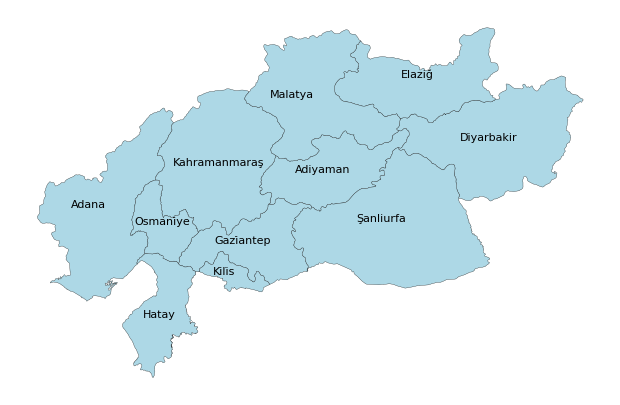

In [7]:
# AOI

gdf_AOI =  gpd.read_file("./shape_files/turkey_administrativelevels0_1_2.zip", layer="tur_polbnda_adm1")
PROVINCES = ['KAHRAMANMARAŞ','ADIYAMAN','KİLİS','OSMANİYE','GAZİANTEP',
     'MALATYA','ŞANLIURFA','DİYARBAKIR','ADANA','HATAY','ELAZIĞ']

# provinces list from https://reliefweb.int/report/turkiye/turkey-earthquake-emergency-situation-report-17022023
# shape from https://data.humdata.org/dataset/cod-ab-tur-rimwge

gdf_AOI = gdf_AOI[gdf_AOI["adm1_tr"].isin(PROVINCES)].copy()
gdf_AOI_regions = gdf_AOI.copy()
gdf_AOI = gdf_AOI.dissolve()

minx, miny, maxx, maxy = gdf_AOI.total_bounds
fig, ax = plt.subplots(figsize=(8,5))
gdf_AOI_regions.plot(ax=ax, color='lightblue', edgecolor="black", linewidth=.2)

for idx, row in gdf_AOI_regions.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax.text(x, y, row["adm1_tr"].title(), fontsize=8, ha='center', va='center')

ax.axis("off");

**Figure 1.** Administrative boundaries of the 11 regions most affected by the 2023 Turkey-Syria earthquakes, used to define the area of interest (AOI). All mobility data are spatially clipped to this region and aggregated using the H3 hierarchical grid system.

In [8]:
H3_res = 8

output_path = Path(f"./spatial_tessellations/gdf_h3_res{H3_res}_EARTHQUAKE.gpkg")

if output_path.exists():
    print("File exists. Loading...")
    gdf_h3 = gpd.read_file(output_path)
else:
    print("File not found. Computing and saving...")
    crs = gdf_AOI.crs
    gdf_h3 = gdf_to_h3(
        gdf_AOI.buffer(0.05).to_crs(crs),
        H3_res
    )
    print(len(gdf_h3))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    gdf_h3.to_file(output_path, driver="GPKG")

File exists. Loading...


### 1.3 Time window and study periods

To capture mobility dynamics before, during, and after the earthquake (which occurred on 6 February 2023), we extract data for the period 2 January to 30 March 2023, spatially clipped to the study area.
We define three analysis periods:
- **Baseline period**: 2 January - 5 February
- **Event period**: 6 February
- **Post-event period**: 7 February - 10 March

The extracted dataset consists of approximately **13.8 million** GPS points generated by **1.7 million** unique users.

In [10]:
time_window = pd.date_range(start=FROM_DATE, end=TO_DATE, freq="D")

# Print summary
print(f"Loading data from {min(time_window):%Y-%m-%d} to {max(time_window):%Y-%m-%d}")
print(f"Time window length: {len(time_window)} days")

Loading data from 2023-01-02 to 2023-03-10
Time window length: 68 days


In [11]:
### Data Loading

path_base = f"s3://wbgggscecovid19dev-mobility/veraset/country=TR"
base_path_save = f"s3://wbgggscecovid19dev-mobility/proposals/561/datasets/"
path_save = f'{base_path_save}{dataset_name}/'

print(path_save)

s3://wbgggscecovid19dev-mobility/proposals/561/datasets/dataset_earthquake_2jan_10mar/


#### Raw-Data Preparation and Loading (slow)

Load from scratch the dataset covering the baseline, event, and recovery periods using **Dask**.  
Apply spatial filtering to reduce the dataset to the Area of Interest (AOI).  
If the filtered subset is small enough to fit in memory, convert it to **Pandas** for faster aggregation and analysis.

In [ ]:
paths_to_load = [path_base+f"/year={d.year}/date={d.strftime('%Y-%m-%d')}/*.parquet" for d in time_window]
len(paths_to_load)

In [ ]:
%%time

# -------------------------
# 0. Load raw GPS dataset (lazy)
columns = ['uid', 'datetime', 'hex_id', 'latitude', 'longitude', 'country']
ddf = dd.read_parquet(paths_to_load,  columns=columns, storage_options={"profile": "ECA"})

# 1. Bounding box filter
ddf = ddf[(ddf.longitude >= minx) & (ddf.longitude <= maxx) &
    (ddf.latitude  >= miny) & (ddf.latitude  <= maxy)]

# -------------------------
# 2. Process datetime (lazy)
ddf['local_datetime'] = (
    dd.to_datetime(ddf['datetime'], utc=True)
      .dt.tz_convert('Europe/Istanbul')
      .dt.tz_localize(None)
)

ddf = ddf[(ddf['local_datetime'] >= FROM_DATE) & (ddf['local_datetime'] <= TO_DATE + pd.Timedelta(days=1))]
ddf['date'] = ddf['local_datetime'].dt.floor('D')

In [ ]:
with ProgressBar():
    df = ddf.compute()

df = df[df["date"]<=max(time_window)]

print("# rows:", len(df))

# Memory usage
mem_bytes = df.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

# Save the dataset for future (faster) loading

ddf_to_save = dd.from_pandas(df)
ddf_to_save.to_parquet(path_save,
                       write_index=False,
                       engine="pyarrow",
                       storage_options= {'profile':'ECA'})

In [ ]:
!aws s3 ls --profile ECA s3://wbgggscecovid19dev-mobility/proposals/561/datasets/

#### Load pre-computed Dataset (fast)


In [13]:
print(f"Loading {dataset_name}")
print(f"folder {path_save}")

ddf = dd.read_parquet(path_save, storage_options={"profile": "ECA"})

with ProgressBar():
    df = ddf.compute()

Loading dataset_earthquake_2jan_10mar
folder s3://wbgggscecovid19dev-mobility/proposals/561/datasets/dataset_earthquake_2jan_10mar/
[########################################] | 100% Completed | 7.15 ss


In [14]:
# Basic cleaning and memory stats

df = df[df["date"]<=max(time_window)]
df = df[["uid", "hex_id", "latitude", "longitude", "local_datetime", "date"]]

print("# rows:", len(df))
print("# users:", df["uid"].nunique())
# Memory usage
mem_bytes = df.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

# rows: 18053688
# users: 2146940
2.14 GB


### Spatial Pre-processing

- Set the desired H3 Spatial resolution
- Perform a precise spatial filtering


Set the desired H3 Spatial resolution

In [15]:
%%time
df = df.drop("hex_id", axis=1)
df = df.h3.geo_to_h3(resolution=H3_res, lat_col="latitude", lng_col="longitude", set_index=False)
df.rename(columns={"h3_08": "hex_id"}, inplace=True)

CPU times: user 55.8 s, sys: 706 ms, total: 56.5 s
Wall time: 56.5 s


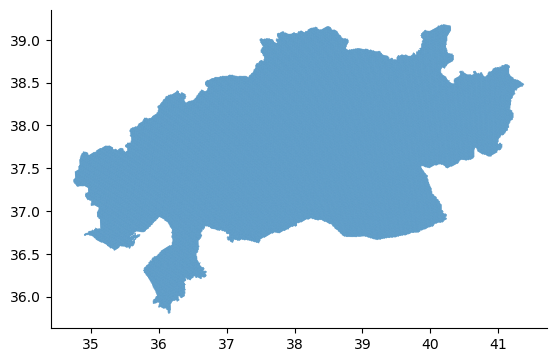

In [16]:
# Spatial Filtering
# We keep only the H3 hexagons of the AOI

gdf_h3_AOI = gpd.sjoin(gdf_h3, gdf_AOI, how="inner", predicate="intersects")
gdf_h3_AOI.plot();

In [17]:
# Apply the filtering
set_h3_AOI = set(gdf_h3_AOI["h3_index"])
df_AOI = df[df["hex_id"].isin(set_h3_AOI)]

Visualize the map **BEFORE** and **AFTER** the spatial filtering

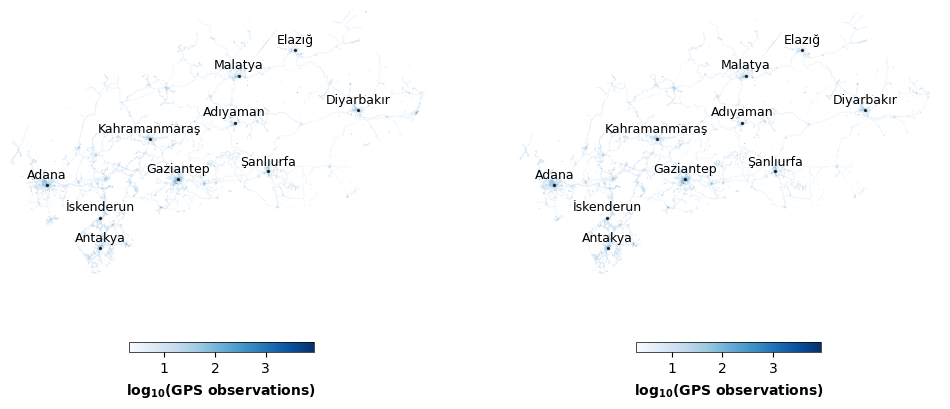

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

cities_annotate = {
    # lat, lng
    "Adana": (36.98943433117843, 35.326172420282305),
    "Gaziantep": (37.066553925023534, 37.37704209994388),
    "Kahramanmaras": (37.5698958853981, 36.93570072180132),
    "Adiyaman": (37.76990755607821, 38.270539522437815),
    "Şanliurfa": (37.16656185525715, 38.79354973671645),
    "Malatya": (38.35603562693763, 38.333616343798724),
    "Elazig": (38.67476387214231, 39.220075677746905),
    "Diyarbakır": (37.92522266899227, 40.207309154679145),
    "Iskenderun": (36.58831906651009, 36.159339548216956),
    "Antakya": (36.20453628503079, 36.16185168379896)
}

cities_to_city_name = {
    "Adana": "Adana",
    "Gaziantep": "Gaziantep",
    "Kahramanmaras": "Kahramanmaraş",
    "Adiyaman": "Adıyaman",
    "Şanliurfa": "Şanlıurfa",
    "Malatya": "Malatya",
    "Elazig": "Elazığ",
    "Diyarbakır": "Diyarbakır",
    "Iskenderun": "İskenderun",
    "Antakya": "Antakya"
}

# Get global bounds from the full hex grid
xmin, ymin, xmax, ymax = gdf_h3_AOI.total_bounds

for ax, dplot in zip(axes, [df, df_AOI]):
    df_gb_count = dplot.groupby(["hex_id", "date"], as_index=False).count()[["hex_id", "uid"]]
    df_hex_avg_points_day = df_gb_count.groupby("hex_id", as_index=False).mean()
    gdf_map = gdf_h3.merge(df_hex_avg_points_day, left_on="h3_index", right_on="hex_id", how="left")
    gdf_map["uid"] = gdf_map["uid"].fillna(0)
    _, _, cbar = plot_map_gdf(gdf_map, col="uid", cmap="Blues", ax=ax, fig=fig)
    
    ax.axis("off");
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    cbar.set_label(r"$\mathbf{log_{10}}$(GPS observations)", weight=600)
    cbar.outline.set_linewidth(0.5)  

    for city in cities_annotate:
        lat, lon = cities_annotate[city]
        ax.scatter(lon, lat, s=2, color="black", alpha=0.7, zorder=3)
        ax.text(lon, lat+0.05, cities_to_city_name[city], fontsize=9, fontweight='500', ha="center", va="bottom", color="black", zorder=5)

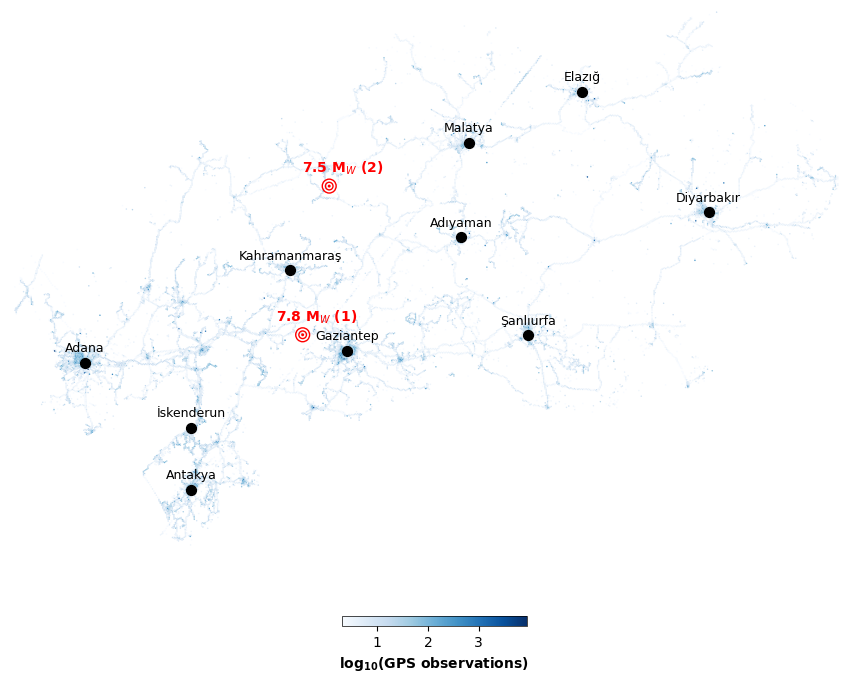

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(12,8))

# Get global bounds from the full hex grid
xmin, ymin, xmax, ymax = gdf_h3_AOI.total_bounds

df_gb_count = df_AOI.groupby(["hex_id", "date"], as_index=False).count()[["hex_id", "uid"]]
df_hex_avg_points_day = df_gb_count.groupby("hex_id", as_index=False).mean()
gdf_map = gdf_h3.merge(df_hex_avg_points_day, left_on="h3_index", right_on="hex_id", how="left")
gdf_map["uid"] = gdf_map["uid"].fillna(0)
_, _, cbar = plot_map_gdf(gdf_map, col="uid", cmap="Blues", ax=ax, fig=fig)

ax.axis("off");
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

cbar.set_label(r"$\mathbf{log_{10}}$(GPS observations)", weight=600)
cbar.outline.set_linewidth(0.5)  


for city in cities_annotate:
    lat, lon = cities_annotate[city]
    ax.scatter(lon, lat, s=50, color="black", alpha=1, zorder=3)
    ax.text(lon, lat+0.05, cities_to_city_name[city], fontsize=9, fontweight='500', ha="center", va="bottom", color="black", zorder=5)


#epicenters
for (lng, lat), label in [[(37.03202, 37.16590), "7.8 M$_W$ (1)"],
                          [(37.23968, 38.08845), "7.5 M$_W$ (2)"]]:
    
    ax.scatter(lng, lat, color="red", marker="o", s=100, facecolors='none')
    ax.scatter(lng, lat, color="red", marker="o", s=30, facecolors='none')
    ax.scatter(lng, lat, color="red", marker=".", s=5, facecolors='none')

    ax.annotate(label, xy=(lng, lat), xytext=(10, 10), textcoords="offset points",
        ha='center', fontsize=10, color='red', fontweight=600)


**Figure 2.** Spatial distribution of GPS observations, shown as the average number of records per H3 hexagon (resolution 8). Higher values represent a greater concentration of recorded activity. The color scale is log₁₀-transformed, with darker blue tones indicating areas with more observations. The locations of the two earthquake epicenters are highlighted with red concentric circles.

In [22]:
print("# rows:", len(df_AOI))
print("# users:", df_AOI["uid"].nunique())
# Memory usage
mem_bytes = df_AOI.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

# rows: 13876847
# users: 1761959
2.17 GB


### 1.4 Preprocessing and filtering

To ensure data quality and reduce noise, we apply a set of preprocessing steps. Users with very low daily activity (fewer than two recorded points per day) are excluded, as they do not provide reliable information on spatial behavior. In addition, H3 hexagons are retained only if they are consistently active throughout the observation period. Hexagons with insufficient activity are removed to avoid unstable estimates and inflated Z-scores.
The final dataset consists of approximately **11 millions** observations from **1,191,076** users covering **1,525** spatial units.


As observed in the data (and discussed in {doc}`Turkey_EDA_QA`), mobility observations are spatially concentrated in major urban centers and along primary transportation corridors. For this reason, subsequent analyses (in particular those related to land use and functional characterization) will focus on these areas.

In [23]:
# Time series: Total Points, Unique Users, and Visited Hexes per Day

df_gb_stats_raw = (
    df_AOI.groupby("date")
      .agg(n_points_count=("uid", "count"), uid_unique=("uid", "nunique"),
           hex_id_unique=("hex_id", "nunique")).reset_index())

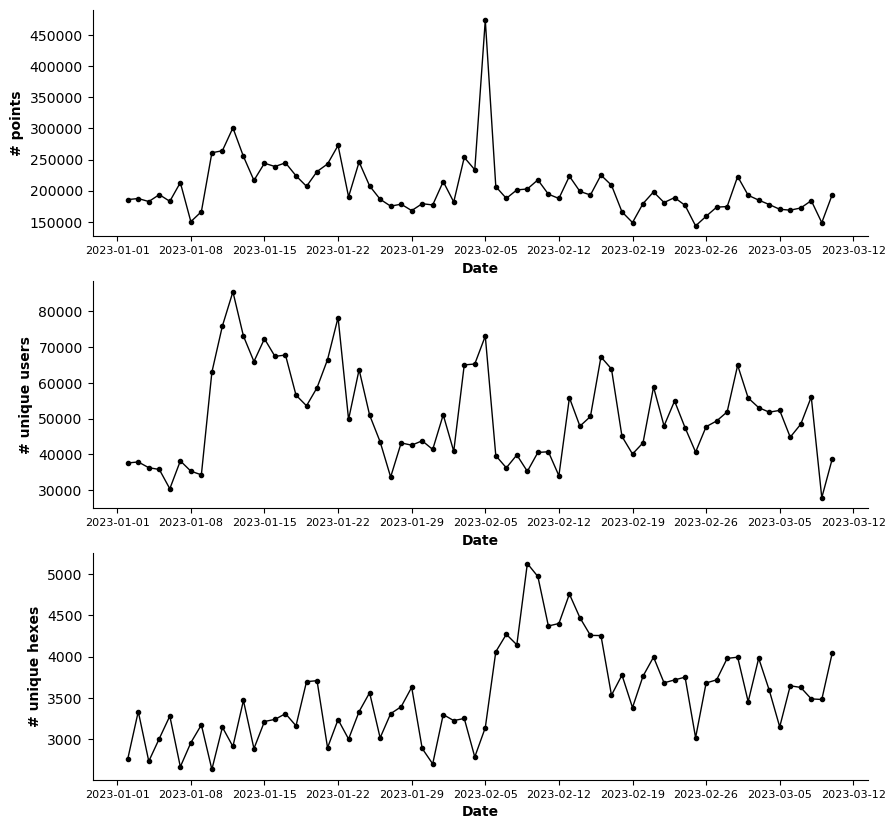

In [24]:
axes_ts = plot_time_series(df_gb_stats_raw, axes=None, color="k", plot_avg=False)
for ax in axes_ts:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.set_xlabel("Date", weight=600)

In [25]:
df_gb_stats_raw.groupby("date").mean().mean()

n_points_count    204071.279412
uid_unique         50741.779412
hex_id_unique       3522.147059
dtype: float64

In [26]:
list_gps_user_day = list(df_AOI.groupby(['uid', 'date']).size().reset_index(name='n_obs')["n_obs"])

print("--- Number of observations per user per day ---")
print("avg. ", round(np.mean(list_gps_user_day),2))
print("Q1", np.quantile(list_gps_user_day, .25))
print("median", np.quantile(list_gps_user_day, .5))
print("Q3", np.quantile(list_gps_user_day, .75))

--- Number of observations per user per day ---
avg.  4.02
Q1 1.0
median 2.0
Q3 2.0


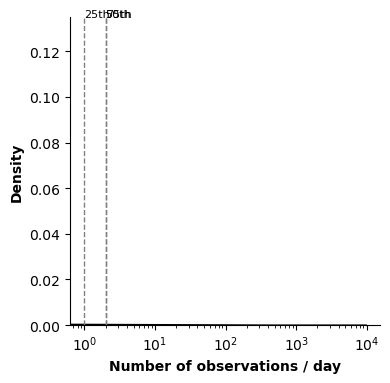

In [27]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.kdeplot(list_gps_user_day, clip=[0, None], c="k", linewidth=1)

p25 = np.quantile(list_gps_user_day, 0.25)
p50 = np.quantile(list_gps_user_day, 0.5)
p75 = np.quantile(list_gps_user_day, 0.75)

for p, label in zip([p25, p50, p75], ["25th", "50th", "75th"]):
    plt.axvline(p, c="grey", linestyle="--", linewidth=1)
    # Annotate the percentile near the line
    plt.text(p, plt.ylim()[1], f"{label}", rotation=0, color='k', fontsize=8)

plt.xscale("log")
ax.set_xlabel("Number of observations / day", weight=600)
ax.set_ylabel("Density", weight=600);

CPU times: user 10.5 s, sys: 1.61 s, total: 12.1 s
Wall time: 12.1 s


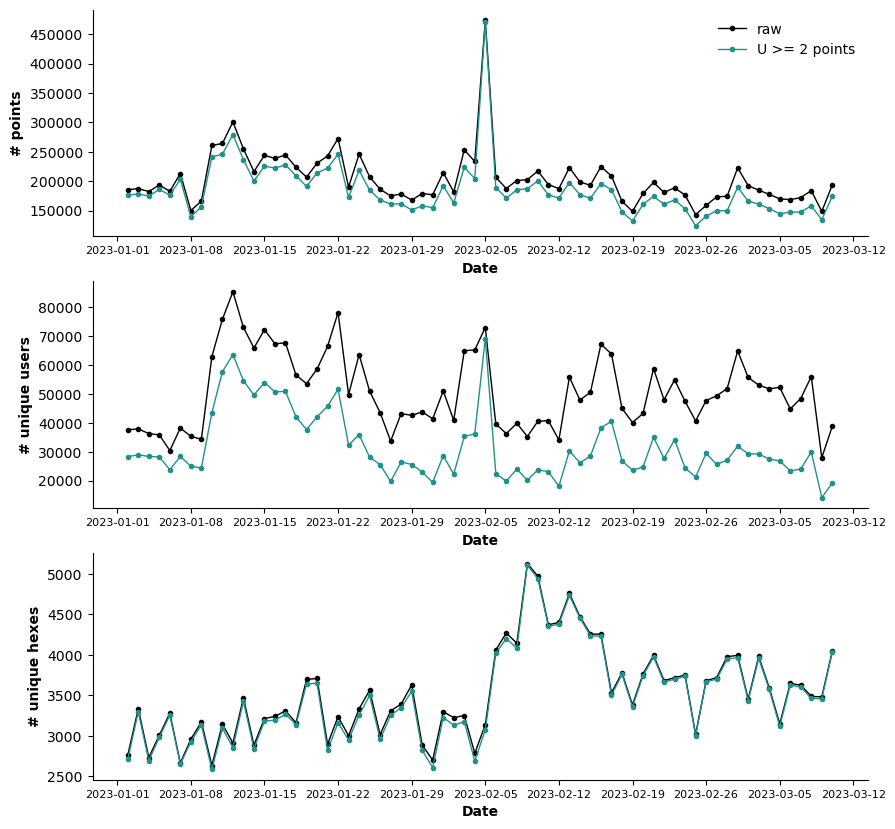

In [28]:
%%time

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=False)

_ = plot_time_series(df_gb_stats_raw, axes=axes, color="k", plot_avg=False, label="raw")

user_min_points = [2]#[2, 3, 5, 10]

palette = sns.color_palette("viridis", n_colors=len(user_min_points))

for user_th, col in zip(user_min_points, palette):

    df_filtered_u = df_AOI[df_AOI.groupby(['uid', 'date'])['uid'].transform('count') >= user_th]
    
    df_gb_stats_filtered = (
    df_filtered_u.groupby("date")
              .agg(
                  n_points_count=("uid", "count"),uid_unique=("uid", "nunique"),
                  hex_id_unique=("hex_id", "nunique")).reset_index())

    del df_filtered_u
    _ = plot_time_series(df_gb_stats_filtered, axes=axes, color=col,
                         plot_avg=False, label=f"U >= {user_th} points")
    '''
    print(f"CV users with >= {user_th} points")
    print("Points: ", coefficient_of_variation(df_gb_stats_filtered["n_points_count"]))
    print("Users: ", coefficient_of_variation(df_gb_stats_filtered["uid_unique"]))
    print("Hexes: ", coefficient_of_variation(df_gb_stats_filtered["hex_id_unique"]))
    print()
    '''

axes[0].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.set_xlabel("Date", weight=600)

**Filter 1:** Remove users per day who do not meet the minimum number of GPS points threshold (noise users).

In [29]:
# filtering parameters
# tip: we can use the median value, it seems robust to me
min_points_per_day = 2

df_filtered_u = df_AOI[df_AOI.groupby(['uid', 'date'])['uid'].transform('count') >= min_points_per_day]

print(f"min points/day: {min_points_per_day}")
print(f"# GPS points: {len(df_filtered_u)} ({len(df_AOI)-len(df_filtered_u)} points removed)")
print("# unique users", df_filtered_u["uid"].nunique())

min points/day: 2
# GPS points: 12584937 (1291910 points removed)
# unique users 1213411


Compute the Urban Space Index
Let's create a dataframe in which:
- each **row** is an **hex**
- each **column** refers to a **day**
- each cell is the number of unique users that visit an hex on a given day (ACTIVITY)

In [30]:
ts_ACTIVITY = df_filtered_u.groupby(["hex_id", "date"])["uid"].nunique().unstack(fill_value=0)
ts_ACTIVITY[:3]

date,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,2023-01-10,2023-01-11,2023-01-12,2023-01-13,2023-01-14,2023-01-15,2023-01-16,2023-01-17,2023-01-18,2023-01-19,2023-01-20,2023-01-21,2023-01-22,2023-01-23,2023-01-24,2023-01-25,2023-01-26,2023-01-27,2023-01-28,2023-01-29,2023-01-30,2023-01-31,2023-02-01,2023-02-02,2023-02-03,2023-02-04,2023-02-05,2023-02-06,2023-02-07,2023-02-08,2023-02-09,2023-02-10,2023-02-11,2023-02-12,2023-02-13,2023-02-14,2023-02-15,2023-02-16,2023-02-17,2023-02-18,2023-02-19,2023-02-20,2023-02-21,2023-02-22,2023-02-23,2023-02-24,2023-02-25,2023-02-26,2023-02-27,2023-02-28,2023-03-01,2023-03-02,2023-03-03,2023-03-04,2023-03-05,2023-03-06,2023-03-07,2023-03-08,2023-03-09,2023-03-10
hex_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
882c3000cdfffff,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
882c300141fffff,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
882c300145fffff,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Filter 2: Remove hexes that do not meet the minimum activity threshold across a sufficient share of days.

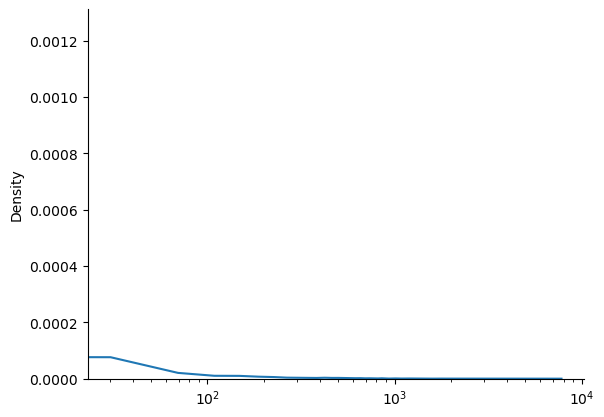

In [31]:
values_list = ts_ACTIVITY.to_numpy().ravel().tolist()
sns.kdeplot(values_list)
plt.xscale("log")

In [32]:
k = 0                   # minimum observations per day      
x_percent = .75 # e.g., x% of days required

# total number of days (columns)
total_days = ts_ACTIVITY.shape[1]

# minimum number of valid days required
min_days_required = x_percent * total_days

# count how many days per hex exceed k
valid_days_per_hex = (ts_ACTIVITY > k).sum(axis=1)

# filter
hexes_to_keep = set(ts_ACTIVITY[valid_days_per_hex >= min_days_required].index)
ts_ACTIVITY_filtered = ts_ACTIVITY[ts_ACTIVITY.index.isin(hexes_to_keep)]

print("total number of hexes:", len(ts_ACTIVITY_filtered))
print("removed hexes:", len(ts_ACTIVITY) - len(ts_ACTIVITY_filtered))

total number of hexes: 1525
removed hexes: 15550


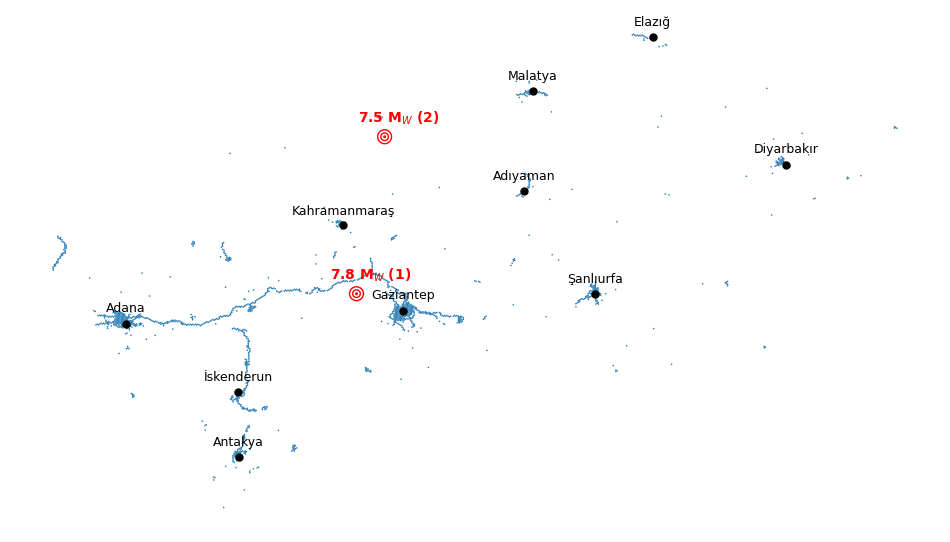

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(12,8))
gdf_h3[gdf_h3["h3_index"].isin(ts_ACTIVITY_filtered.index)].plot(ax=ax)
ax.axis("off");
for city in cities_annotate:
    lat, lon = cities_annotate[city]
    ax.scatter(lon, lat, s=25, color="black", alpha=1, zorder=3)
    ax.text(lon, lat+0.05, cities_to_city_name[city], fontsize=9, fontweight='500', ha="center", va="bottom", color="black", zorder=5)


#epicenters
for (lng, lat), label in [[(37.03202, 37.16590), "7.8 M$_W$ (1)"],
                          [(37.23968, 38.08845), "7.5 M$_W$ (2)"]]:
    
    ax.scatter(lng, lat, color="red", marker="o", s=100, facecolors='none')
    ax.scatter(lng, lat, color="red", marker="o", s=30, facecolors='none')
    ax.scatter(lng, lat, color="red", marker=".", s=5, facecolors='none')

    ax.annotate(label, xy=(lng, lat), xytext=(10, 10), textcoords="offset points",
        ha='center', fontsize=10, color='red', fontweight=600)


In [35]:
G = set(ts_ACTIVITY_filtered.index)

In [36]:
len(df_filtered_u[df_filtered_u["hex_id"].isin(G)])

11009977

In [37]:
df_filtered_u[df_filtered_u["hex_id"].isin(G)]["uid"].nunique()

1191076

In [38]:
df_filtered_u[df_filtered_u["hex_id"].isin(G)]["hex_id"].nunique()

1525

## 2. Methods

The analysis follows the methodological framework described in {doc}`Methodology` and applied in the previous case study. In brief, we use the **Urban Space Usage Index** ($I$), defined as the **share of unique users visiting each H3 hexagon**. The number of unique users is used as a proxy for human presence, under the assumption that higher user counts correspond to greater spatial utilization.

To **quantify deviations** from typical conditions, we compute **Z-scores**, which measure how strongly observed activity deviates from baseline levels. Positive values indicate higher activity, while negative values indicate lower activity compared to baseline conditions.

**Compute the number of unique users that visit an hex on a given day (to normalize ACTIVITY)**

In [39]:
total_unique_users = df_filtered_u.groupby("date")["uid"].nunique()
ts_USI = ts_ACTIVITY_filtered / total_unique_users

ts_USI[:1]

date,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,2023-01-10,2023-01-11,2023-01-12,2023-01-13,2023-01-14,2023-01-15,2023-01-16,2023-01-17,2023-01-18,2023-01-19,2023-01-20,2023-01-21,2023-01-22,2023-01-23,2023-01-24,2023-01-25,2023-01-26,2023-01-27,2023-01-28,2023-01-29,2023-01-30,2023-01-31,2023-02-01,2023-02-02,2023-02-03,2023-02-04,2023-02-05,2023-02-06,2023-02-07,2023-02-08,2023-02-09,2023-02-10,2023-02-11,2023-02-12,2023-02-13,2023-02-14,2023-02-15,2023-02-16,2023-02-17,2023-02-18,2023-02-19,2023-02-20,2023-02-21,2023-02-22,2023-02-23,2023-02-24,2023-02-25,2023-02-26,2023-02-27,2023-02-28,2023-03-01,2023-03-02,2023-03-03,2023-03-04,2023-03-05,2023-03-06,2023-03-07,2023-03-08,2023-03-09,2023-03-10
hex_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
882c305695fffff,0.000035,0.000104,0.000106,0.000142,0.000126,0.00007,0.00008,0.000082,0.000046,0.000069,0.000016,0.000018,0.00002,0.000019,0.000039,0.000059,0.000048,0.000027,0.000071,0.000044,0.000019,0.000062,0.000083,0.000035,0.000039,0.000101,0.000151,0.000078,0.0,0.000103,0.00007,0.000045,0.000057,0.000028,0.0,0.000089,0.000302,0.000042,0.000099,0.000042,0.000086,0.000111,0.000066,0.0,0.000105,0.0,0.000025,0.000037,0.000042,0.00004,0.000029,0.0,0.0,0.0,0.000047,0.000068,0.000039,0.000074,0.0,0.000068,0.0,0.000036,0.000037,0.000043,0.000042,0.000033,0.000141,0.0


## 3. Results

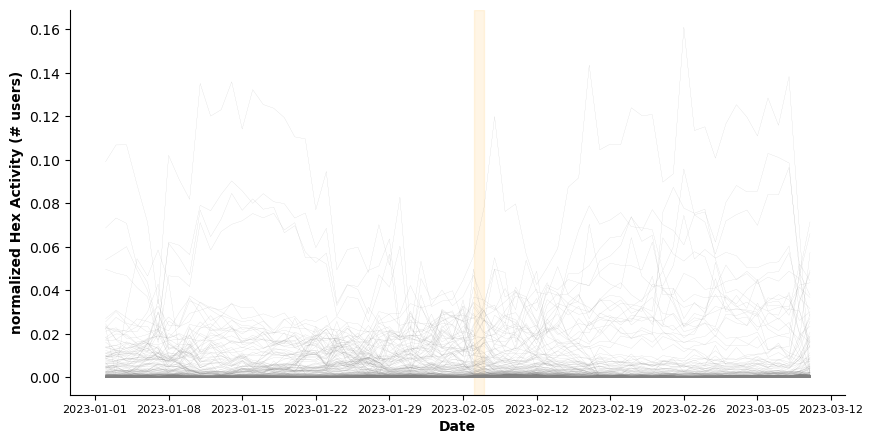

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

for hex_id in ts_USI.index:
    ax.plot(ts_USI.columns, ts_USI.loc[hex_id], alpha=0.6, linewidth=0.1, color="grey")

#ax.plot(ts.mean(), c="k")

# ax.axvline(pd.to_datetime("2023-10-28 00:00"), color="k", linestyle="--", linewidth=0.5)
# ax.axvline(pd.to_datetime("2023-10-29 23:59"), color="k", linestyle="--", linewidth=0.5)

ax.axvspan(EVENT_START, EVENT_END, color="orange", alpha=0.1)

ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("normalized Hex Activity (# users)", weight=600);
#plt.ylim(0, 200);

### 3.1 Temporal evolution of urban activity

The temporal evolution of the Urban Space Usage Index reveals a clear increase in activity on the day of the earthquake (6 February 2023) and in the following days (Figure 3).

Activity levels increase during the event and remain elevated in the following days before gradually returning toward baseline conditions. This pattern is consistent with the dynamics of an unexpected natural disaster, where increased activity is indicative of coordinated response and displacement.

Overall, the time series highlights a clear shift in urban activity during the event period compared to typical conditions, demonstrating the ability of the index to capture large-scale behavioral responses to sudden shocks.

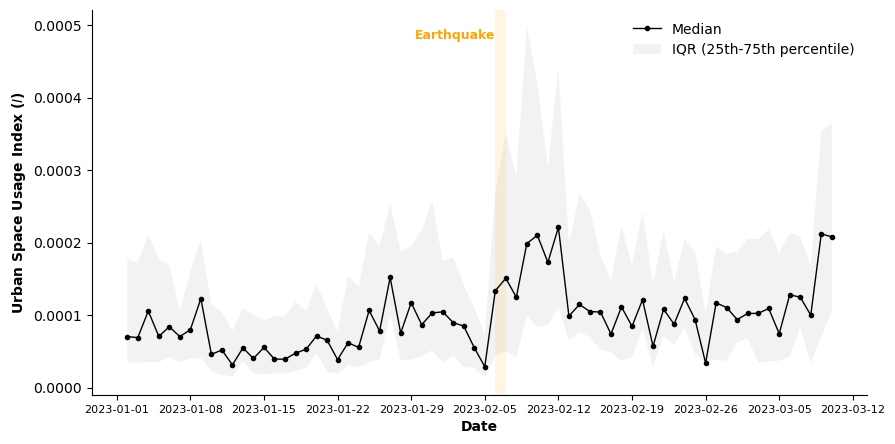

In [41]:
# Calculate the mean and IQR
median_values = ts_USI.median(axis=0)
q25 = ts_USI.quantile(0.25, axis=0)
q75 = ts_USI.quantile(0.75, axis=0)

# Create the plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

# Plot the mean line
ax.plot(ts_USI.columns, median_values, c="k", label="Median", linewidth=1, marker=".")

# Plot the shaded area for the IQR
ax.fill_between(ts_USI.columns, q25, q75, color="grey", alpha=0.1, label="IQR (25th-75th percentile)", edgecolor="none")

# Highlight the event span
ax.axvspan(EVENT_START, EVENT_END, color="orange", alpha=0.1, linewidth=0)
ax.text(EVENT_START, 0.95, "Earthquake", color="orange", transform=ax.get_xaxis_transform(), fontsize=9,
        weight="bold", va="top", ha="right")#, bbox=dict(facecolor="orange", edgecolor="none", boxstyle="round,pad=0.3", alpha=0.25))


# Format the x-axis (dates)
ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("Urban Space Usage Index ($I$)", weight=600)

#ax.set_ylim(None, 0.02)

# Add a legend
ax.legend();

**Figure 3.** Time series of the median Urban Space Usage Index (I) across all hexagonal cells in the area of interest, with the shaded area representing the interquartile range. The highlighted band marks the earthquake (6 February 2023), after which a clear increase in observed activity is observed.

### 3.2 Anomaly detection

To assess whether observed changes correspond to statistically significant deviations from typical conditions, we use the Z-score, which measures how many standard deviations observed activity deviates from its baseline.


As shown in Figure 4, during the baseline period, **Z-scores fluctuate around zero**, indicating stable and expected conditions. On **6 February**, the median Z-score exhibits a **sharp increase** (from -0.75 on 5 February to 1.36 on 6 February), marking the start of an extreme positive anomaly due to increased activity relative to normal conditions.

In the days following the earthquake, Z-scores continue to rise, reaching a median value close to 4 on 9 February, three days after the event. This lagged response is consistent with the progressive mobilization of emergency services, delayed evacuations, and ongoing humanitarian activities.

From approximately 13 February onward, Z-scores gradually decrease, approaching a new steady state that remains slightly above baseline levels, likely reflecting continued recovery operations, debris removal, and reconstruction activities.

The sharp increase in Z-scores coinciding with the earthquake strongly suggests that the observed disruptions in mobility are directly associated with the event.

In [42]:
baseline = ts_USI.loc[:, "2023-01-02":"2023-02-05"]
print(baseline.shape)

baseline_mean = baseline.mean(axis=1)
baseline_std = baseline.std(axis=1)

(1525, 35)


In [43]:
# subtraction and division row-wise to compute the z-score

z_scores = ts_USI.sub(baseline_mean, axis=0).div(baseline_std, axis=0)
z_scores = z_scores.dropna()

z_scores[:1]

date,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,2023-01-10,2023-01-11,2023-01-12,2023-01-13,2023-01-14,2023-01-15,2023-01-16,2023-01-17,2023-01-18,2023-01-19,2023-01-20,2023-01-21,2023-01-22,2023-01-23,2023-01-24,2023-01-25,2023-01-26,2023-01-27,2023-01-28,2023-01-29,2023-01-30,2023-01-31,2023-02-01,2023-02-02,2023-02-03,2023-02-04,2023-02-05,2023-02-06,2023-02-07,2023-02-08,2023-02-09,2023-02-10,2023-02-11,2023-02-12,2023-02-13,2023-02-14,2023-02-15,2023-02-16,2023-02-17,2023-02-18,2023-02-19,2023-02-20,2023-02-21,2023-02-22,2023-02-23,2023-02-24,2023-02-25,2023-02-26,2023-02-27,2023-02-28,2023-03-01,2023-03-02,2023-03-03,2023-03-04,2023-03-05,2023-03-06,2023-03-07,2023-03-08,2023-03-09,2023-03-10
hex_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
882c305695fffff,-0.638159,1.142468,1.198824,2.135702,1.73109,0.279197,0.52761,0.576811,-0.35954,0.249787,-1.14921,-1.081335,-1.033617,-1.075706,-0.530606,-0.021066,-0.318882,-0.866961,0.299584,-0.418162,-1.053573,0.056077,0.618438,-0.632961,-0.53907,1.085105,2.373963,0.478394,-1.559084,1.130492,0.26124,-0.387918,-0.08163,-0.838217,-1.559084,0.766543,6.314033,-0.474217,1.034889,-0.461898,0.695497,1.326216,0.158873,-1.559084,1.17914,-1.559084,-0.915549,-0.589345,-0.455213,-0.50486,-0.813857,-1.559084,-1.559084,-1.559084,-0.334713,0.211455,-0.541854,0.363387,-1.559084,0.22191,-1.559084,-0.609084,-0.588009,-0.444174,-0.47354,-0.688758,2.13126,-1.559084


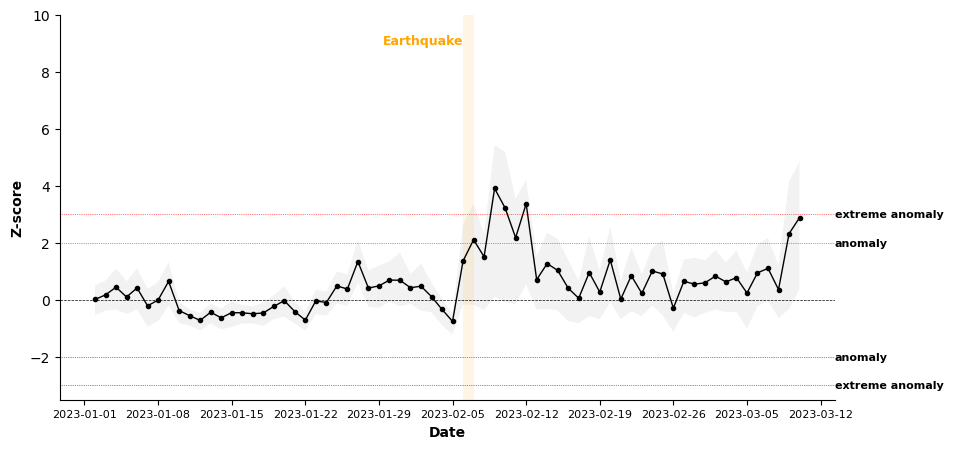

In [44]:
mean_values = z_scores.mean(axis=0)
q25 = z_scores.quantile(0.25, axis=0)
q75 = z_scores.quantile(0.75, axis=0)

# Create the plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

# --- Plot all series at once ---
#ax.plot(x, y.T, color="grey", alpha=0.15, linewidth=0.5)

# Plot the mean line
ax.plot(z_scores.mean(), c="k", linewidth=1, zorder=99, marker=".")  # average line

# Plot the shaded area for the IQR with no border
ax.fill_between(z_scores.columns, q25, q75, color="grey", alpha=0.1, edgecolor="none", label="IQR (25th-75th percentile)")

# Add horizontal line at 0
ax.axhline(0, c="k", linewidth=.5, linestyle="--")

x_lims = ax.set_xlim()

# --- Anomaly thresholds ---
for anomaly_th, anomaly_label in zip([2, 3], ["anomaly", "extreme anomaly"]):
    ax.axhline(anomaly_th, c="red", linewidth=.5, linestyle=":")
    ax.axhline(-anomaly_th, c="blue", linewidth=.5, linestyle=":")
    
    # Adding labels for anomalies
    plt.text(x_lims[1], anomaly_th, anomaly_label, ha="left", va="center", weight=600, size=8)
    plt.text(x_lims[1], -anomaly_th, anomaly_label, ha="left", va="center", weight=600, size=8)
    

# Highlight the event span
ax.axvspan(EVENT_START, EVENT_END, color="orange", alpha=0.1, linewidth=0)
ax.text(EVENT_START, 0.95, "Earthquake", color="orange", transform=ax.get_xaxis_transform(), fontsize=9,
        weight="bold", va="top", ha="right")#, bbox=dict(facecolor="orange", edgecolor="none", boxstyle="round,pad=0.3", alpha=0.25))


# Format the x-axis (dates)
ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("Z-score", weight=600)

# Optional: limit y-axis if necessary
plt.ylim(-3.5, 10)

plt.show()

**Figure 4.** Time series of the average Z-score of the Urban Space Usage Index across hexagons in the area of interest, with the shaded area representing the interquartile range. Horizontal dashed lines indicate anomaly thresholds. The highlighted band marks the earthquake (6 February 2023).

In [45]:
pd.DataFrame(z_scores.mean())[30:50].T

date,2023-02-01,2023-02-02,2023-02-03,2023-02-04,2023-02-05,2023-02-06,2023-02-07,2023-02-08,2023-02-09,2023-02-10,2023-02-11,2023-02-12,2023-02-13,2023-02-14,2023-02-15,2023-02-16,2023-02-17,2023-02-18,2023-02-19,2023-02-20
0,0.427997,0.480125,0.116887,-0.333352,-0.752008,1.364674,2.108737,1.514156,3.907606,3.223866,2.180832,3.369314,0.71096,1.27482,1.033715,0.410545,0.059495,0.958751,0.277471,1.402994


### 3.3 Spatial distribution of anomalies

The spatial distribution of Z-scores on 6 February (Figure 5) reveals how the earthquake affects different parts of the region. As expected from the dataset characteristics, spatial coverage is sparse and concentrated in approximately 10 major urban centers, as well as along key transportation corridors.

Urban areas exhibit positive anomalies, reflecting the concentration of emergency response efforts, humanitarian assistance, and population movements. Similarly, major road networks show high levels of observed mobility, likely associated with evacuations, the movement of rescue teams, and the delivery of aid.

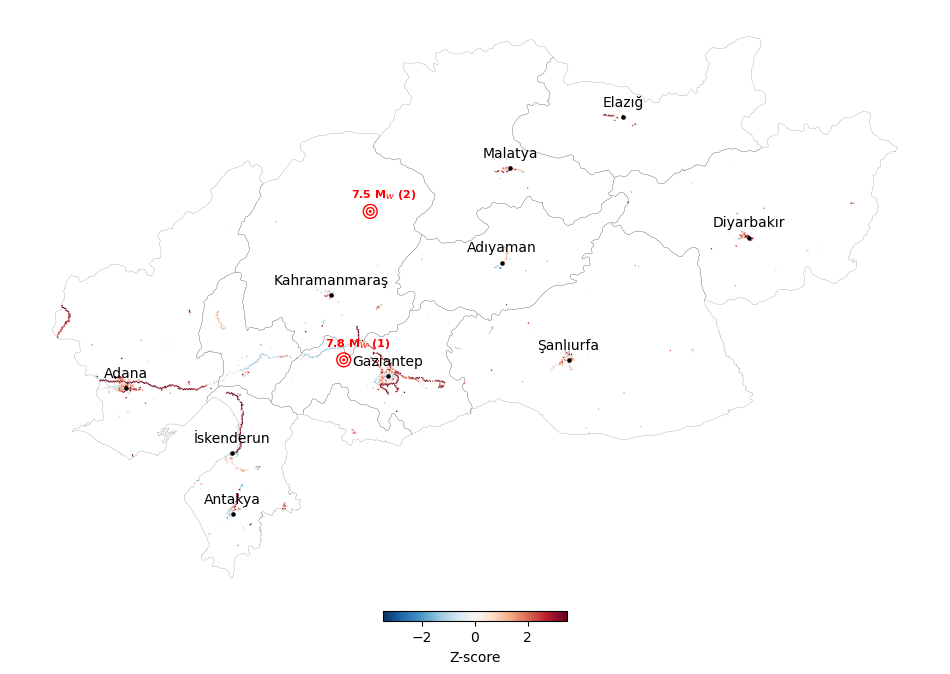

In [47]:
day_plot = "2023-02-06"

df_gdf_zscore = z_scores[[day_plot]].copy()
df_gdf_zscore["z_score"] = df_gdf_zscore[day_plot]
df_gdf_zscore_plot = df_gdf_zscore[["z_score"]]

# threshold
#df_gdf_zscore_plot = df_gdf_zscore[df_gdf_zscore["z_score"]<]

vmax = 3.5
vmin =-vmax


gdf_map_zscore = gdf_h3.merge(df_gdf_zscore_plot, left_on="h3_index", right_on="hex_id", how="inner")

fig, ax = plt.subplots(figsize=(12,8))
gdf_map_zscore.plot(column="z_score", cmap="RdBu_r", legend=False, ax=ax, vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin, vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.015, pad=0.01, orientation="horizontal")
cbar.set_label("Z-score")
ax.axis("off");

for city in cities_annotate:
    lat, lon = cities_annotate[city]
    ax.scatter(lon, lat, s=5, color="black", alpha=1, zorder=3)
    ax.text(lon, lat+0.05, cities_to_city_name[city], fontsize=10, fontweight='500', ha="center", va="bottom", color="black", zorder=5)


#epicenters
for (lng, lat), label in [[(37.03202, 37.16590), "7.8 M$_W$ (1)"],
                          [(37.23968, 38.08845), "7.5 M$_W$ (2)"]]:
    
    ax.scatter(lng, lat, color="red", marker="o", s=100, facecolors='none')
    ax.scatter(lng, lat, color="red", marker="o", s=30, facecolors='none')
    ax.scatter(lng, lat, color="red", marker=".", s=5, facecolors='none')

    ax.annotate(label, xy=(lng, lat), xytext=(10, 10), textcoords="offset points",
        ha='center', fontsize=8, color='red', fontweight=600)

gdf_AOI_regions.plot(ax=ax, facecolor="none", linewidth=.1);

**Figure 5.** Map of the Z-score of the Urban Space Usage Index across H3 hexagonal cells in the area of interest on 6 February 2023. Warmer colors indicate higher-than-expected activity, highlighting spatial heterogeneity with stronger anomalies concentrated in urban areas and along major transportation corridors.

At the **regional (province) level**, the intensity of anomalies varies substantially. **Hatay** (Z = 4.25) and **Adana** (Z = 3.63) exhibit the **strongest increases**, indicating particularly intense mobility responses. Osmaniye (Z = 1.83), Kahramanmaraş (Z = 1.52), and Elazığ (Z = 1.33) also show notable positive anomalies, while regions such as Gaziantep, Kilis, and Diyarbakır display more moderate increases.
By contrast, Adıyaman exhibits a negative anomaly (Z = -0.88), suggesting reduced observed activity. This may reflect severe local disruption, limited mobility, or data sparsity in the immediate aftermath of the earthquake. Figure 6 shows an interactive plot of the time series of Z-score for each region.

<div style="width: 100%; font-size: 11px;">
    
|         |   Hatay  |   Adana  | Osmani̇ye | Kahramanmaraş |  Elaziğ  |   Ki̇li̇s  | Gazi̇antep | Di̇yarbakir |  Malatya | Şanliurfa |  Adiyaman |
|---------|:--------:|:--------:|:--------:|:-------------:|:--------:|:--------:|:---------:|:----------:|:--------:|:---------:|:---------:|
| Z-score | 4.25 | 3.63 | 1.83 | 1.52      | 1.33 | 1.23 | 1.21  | 0.91   | 0.89 | 0.79  | -0.88 |


</div>

In [48]:
#  Z-score by province

gdf_AOI_regions = gdf_AOI_regions[["adm1_tr", "geometry"]]
h3m, regm = gdf_h3.to_crs(3035), gdf_AOI_regions.to_crs(3035)
ov = gpd.overlay(h3m, regm, how="intersection")
ov["area"] = ov.geometry.area
best = ov.loc[ov.groupby("h3_index")["area"].idxmax()]
gdf_h3 = gdf_h3.merge(best[["h3_index", "adm1_tr"]], on="h3_index", how="left")

In [52]:
z_score_event = z_scores.loc[:, "2023-02-06":"2023-02-09"]
z_score_event = z_score_event.mean(axis=1).to_frame("z_score")

df_z_region = z_score_event.reset_index().merge(gdf_h3, left_on="hex_id", right_on="h3_index", how="left")
df_z_region = df_z_region[["adm1_tr", "z_score"]]
#df_z_region["adm1_tr"] = df_z_region["adm1_tr"].apply(lambda x: x.title())

df_z_region.groupby("adm1_tr").mean().sort_values("z_score", ascending=False).round(2).T

adm1_tr,HATAY,ADANA,OSMANİYE,KAHRAMANMARAŞ,ELAZIĞ,KİLİS,GAZİANTEP,DİYARBAKIR,MALATYA,ŞANLIURFA,ADIYAMAN
z_score,4.25,3.62,1.83,1.52,1.33,1.23,1.21,0.91,0.89,0.79,-0.88


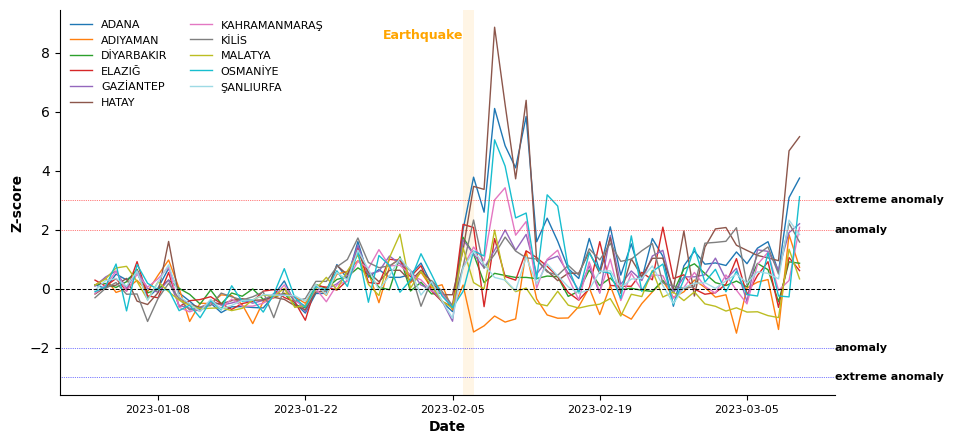

In [53]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

regions = gdf_AOI_regions["adm1_tr"].unique()

cmap = mpl.colormaps.get_cmap("tab20").resampled(len(regions))

for ind_r, region in enumerate(regions):

    h3_in_region = set(gdf_h3[gdf_h3["adm1_tr"] == region]["h3_index"])
    z_scores_region = z_scores[z_scores.index.isin(h3_in_region)]

    color = cmap(ind_r)
    ax.plot(z_scores_region.mean(), label=region, linewidth=1, color=color)
    
    
x_lims = ax.set_xlim()

# --- Anomaly thresholds ---
for anomaly_th, anomaly_label in zip([2, 3], ["anomaly", "extreme anomaly"]):
    ax.axhline(anomaly_th, c="red", linewidth=.5, linestyle=":")
    ax.axhline(-anomaly_th, c="blue", linewidth=.5, linestyle=":")
    
    # Adding labels for anomalies
    plt.text(x_lims[1], anomaly_th, anomaly_label, ha="left", va="center", weight=600, size=8)
    plt.text(x_lims[1], -anomaly_th, anomaly_label, ha="left", va="center", weight=600, size=8)
    
# Highlight the event span
ax.axvspan(EVENT_START, EVENT_END, color="orange", alpha=0.1, linewidth=0)
ax.text(EVENT_START, 0.95, "Earthquake", color="orange", transform=ax.get_xaxis_transform(), fontsize=9,
        weight="bold", va="top", ha="right")#, bbox=dict(facecolor="orange", edgecolor="none", boxstyle="round,pad=0.3", alpha=0.25))    
    
#plt.text(pd.to_datetime("2023-10-29 12:00"), 8, "event", ha="center", weight=600)
ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("Z-score", weight=600)
ax.axhline(0, c="k", linewidth=.75, linestyle="--")
plt.legend(ncols=2, loc="upper left", fontsize=8);

In [54]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.palettes import Category20
from bokeh.models import Span, Label, BoxAnnotation, Legend, LegendItem

output_notebook()  # display in Jupyter

regions = gdf_AOI_regions["adm1_tr"].unique()
n_regions = len(regions)
palette = Category20[20]  # up to 20 colors
colors = [palette[i % 20] for i in range(n_regions)]

p = figure(width=770, height=400, x_axis_type="datetime", title="Z-scores by Region")

# Keep track of renderers for legend
legend_items = []

# Plot each region
for ind_r, (region, color) in enumerate(zip(regions, colors)):
    h3_in_region = set(gdf_h3[gdf_h3["adm1_tr"] == region]["h3_index"])
    z_scores_region = z_scores[z_scores.index.isin(h3_in_region)]
    
    mean_series = z_scores_region.mean()
    x = pd.to_datetime(mean_series.index)
    y = mean_series.values
    
    r = p.line(x, y, line_width=1, color=color)
    legend_items.append(LegendItem(label=region.title(), renderers=[r]))

# Horizontal anomaly lines
for anomaly_th, anomaly_label, color in zip([2, 3], ["anomaly", "extreme anomaly"], ["red", "red"]):
    span = Span(location=anomaly_th, dimension='width', line_color=color, line_dash='dotted', line_width=1)
    p.add_layout(span)
    span_neg = Span(location=-anomaly_th, dimension='width', line_color="blue", line_dash='dotted', line_width=1)
    p.add_layout(span_neg)
    
    label = Label(x=pd.to_datetime(z_scores.columns[0]), y=anomaly_th, text=anomaly_label,
                  text_font_size="8pt", text_align="left", text_baseline="middle")
    p.add_layout(label)
    label_neg = Label(x=pd.to_datetime(z_scores.columns[0]), y=-anomaly_th, text=anomaly_label,
                      text_font_size="8pt", text_align="left", text_baseline="middle")
    p.add_layout(label_neg)

# Highlight event span
event_span = BoxAnnotation(left=EVENT_START, right=EVENT_END, fill_color='orange', fill_alpha=0.1)
p.add_layout(event_span)
event_label = Label(x=EVENT_START, y=max(z_scores.values.flatten())*0.95, text="Earthquake",
                    text_color="orange", text_font_size="9pt", text_font_style="bold")
p.add_layout(event_label)

# Axes labels
p.xaxis.axis_label = "Date"
p.yaxis.axis_label = "Z-score"
p.yaxis.axis_label_text_font_style = "bold"
p.xaxis.axis_label_text_font_style = "bold"

# Zero line
zero_line = Span(location=0, dimension='width', line_color='black', line_dash='dashed', line_width=1)
p.add_layout(zero_line)

# Create 2-column legend
legend = Legend(items=legend_items, location="top_left", label_text_font_size="7pt", orientation="vertical", label_text_font_style="bold")
legend.ncols = 2
p.add_layout(legend)
p.legend.click_policy = "hide"

show(p)

Loading BokehJS ...

**Figure 6.** Time series of the Z-score of the Urban Space Usage Index for each region in the area of interest. The highlighted band marks the earthquake (6 February 2023).

The interactive map in Figure 7 allows exploration of the full time series of Z-scores. Deviations from baseline conditions remain close to zero during the baseline period, increase sharply on the event day, and remain elevated for several days before gradually declining toward baseline levels.

In [3]:
from IPython.display import HTML
HTML('<iframe width="100%" height="800px" src="https://studio.foursquare.com/map/public/63bc341b-8462-49d9-987e-ba9e91036b28/embed" frameborder="0" allowfullscreen></iframe>')

**Figure 7.** Interactive map of the Z-score of the Urban Space Usage Index across H3 hexagonal cells in the area of interest. The animation shows the day-by-day evolution of activity levels, with colors indicating relative intensity. The play control allows exploration of temporal dynamics before, during, and after the earthquake.

### 3.4 Spatial and Functional Characterization of Activity

To interpret the spatial distribution of activity, each hexagonal cell is associated with both land use and functional activity. For land use, we assign each hexagon a dominant category (e.g., residential, commercial, industrial, green areas), capturing the physical organization of urban space. In contrast, the functional layer is derived from POIs: for each hexagon, we count the number of POIs in different activity categories (e.g., schools, hospitals, parks, transport hubs, commercial venues). For more details on the land use and functional activity methodology, refer to {doc}`Methodology_land_usage`.

Given that observations are concentrated in a limited number of urban areas, the analysis focuses on the **10 major cities** identified in the dataset, both individually and in aggregate.

Land-use and POI data are derived from OpenStreetMap (OSM) and accessed via Geofabrik extracts (https://download.geofabrik.de/europe/turkey.html). To ensure temporal consistency with the mobility data, which refer to 2023, we use OSM snapshots from January 2023. © OpenStreetMap contributors, licensed under the Open Database License (ODbL).



In [55]:
z_scores_baseline = z_scores.loc[:, "2023-01-02":"2023-02-05"]
z_scores_event = z_scores.loc[:, "2023-02-06":"2023-02-09"]

activity_baseline = ts_USI.loc[:, "2023-01-02":"2023-02-05"]
activity_event = ts_USI.loc[:, "2023-02-06":"2023-02-09"]

z_base_mean = z_scores_baseline.mean(axis=1).to_frame("z_base_mean").reset_index()
z_event_mean = z_scores_event.mean(axis=1).to_frame("z_event_mean").reset_index()
act_base_mean = activity_baseline.mean(axis=1).to_frame("act_base_mean").reset_index()
act_event_mean = activity_event.mean(axis=1).to_frame("act_event_mean").reset_index()

In [56]:
cities_landuse = ["Adana", "Adiyaman", "Antakya", "Diyarbakir", "Elazig", 
                  "Gaziantep", "Iskenderun", "Kahramanmaras", "Malatya", "Sanliurfa"]

list_gdfs = []
for city in cities_landuse:
    gdf_city_tmp =  gpd.read_file(f"./land_usage/land_usage_h3_res8_{city}.gpkg")
    gdf_city_tmp = gdf_city_tmp.rename(columns={"h3_index": "hex_id"})
    gdf_city_tmp["city"] = city
    list_gdfs.append(gdf_city_tmp)

gdf_cities_LU = pd.concat(list_gdfs, ignore_index=True)

In [57]:
#Merge everything

gdf_cities_LU = (
    gdf_cities_LU
    .merge(z_base_mean, on="hex_id", how="left")
    .merge(z_event_mean, on="hex_id", how="left")
    .merge(act_base_mean, on="hex_id", how="left")
    .merge(act_event_mean, on="hex_id", how="left"))

gdf_cities_LU = gdf_cities_LU.dropna(subset=["z_base_mean"])

len(gdf_cities_LU)

891

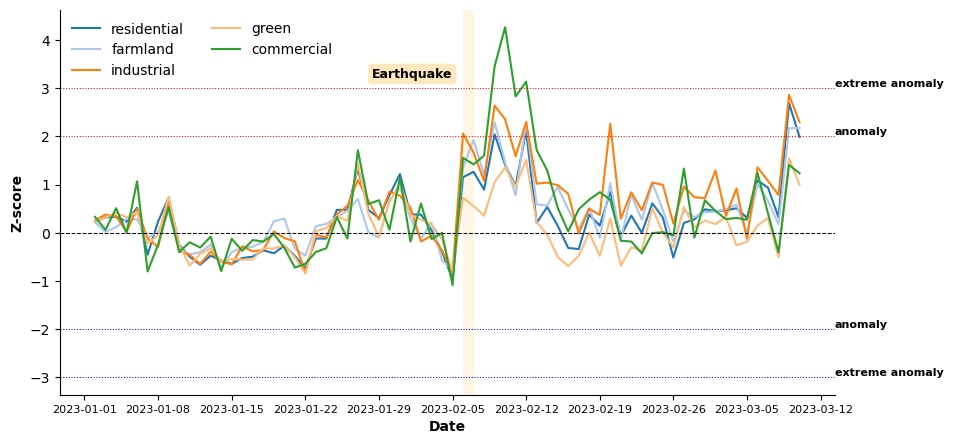

In [58]:
filter_cities = []

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

label_col = "land_use"

gdf_filtered = gdf_cities_LU[(gdf_cities_LU[label_col]!="other")&(gdf_cities_LU[label_col]!="none")]
gdf_filtered = gdf_filtered.dropna(subset=[label_col])

cmap = mpl.colormaps.get_cmap("tab20")


for ind, category in enumerate(['residential', 'farmland', 'industrial', 'green','commercial']):

    gdf_category = gdf_filtered[gdf_filtered[label_col]==category]
    #print(gdf_category["city"].unique())
    if len(filter_cities)>0:
        gdf_category = gdf_category[gdf_category["city"].isin(filter_cities)]
    #print(gdf_category["city"].unique())
    h3_in_category = set(gdf_category["hex_id"])
    z_scores_category = z_scores[z_scores.index.isin(h3_in_category)]
    #print(category, z_scores_category.shape)

    x = pd.to_datetime(z_scores_category.columns)
    y = z_scores_category.values
    
    # --- Plot all series at once  ---
    #ax.plot(x, y.T, color="grey", alpha=0.15, linewidth=0.5)
    color = cmap(ind)
    #color = landuse_colors[category]
        
    #ax.plot(z_scores_category.mean(), label=category, color=color)
    ax.plot(x, z_scores_category.mean(axis=0), label=category, color=color)

plt.legend(ncol=2, loc="upper left")


# --- Event window shading ---
ax.axvspan(EVENT_START, EVENT_END, color="orange", alpha=0.1, linewidth=0)
ax.text(pd.to_datetime("2023-02-05"), 0.85, "Earthquake", transform=ax.get_xaxis_transform() ,fontsize=9,
        weight="bold", va="top", ha="right", bbox=dict(
    facecolor="orange", edgecolor="none", boxstyle="round,pad=0.3", alpha=0.25))



x_lims = ax.set_xlim()

# --- Anomaly thresholds ---

for anomaly_th, anomaly_label in zip([2, 3], ["anomaly", "extreme anomaly"]):
    ax.axhline(anomaly_th, c="red", linewidth=.75, linestyle=":")
    ax.axhline(-anomaly_th, c="blue", linewidth=.75, linestyle=":")
    
    # Adding labels for anomalies
    plt.text(x_lims[1], anomaly_th + 0.1, anomaly_label, ha="left", va="center", weight=600, size=8)
    plt.text(x_lims[1], -anomaly_th + 0.1, anomaly_label, ha="left", va="center", weight=600, size=8)


ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("Z-score", weight=600)
ax.axhline(0, c="k", linewidth=.75, linestyle="--");


#### Land Use Analysis

**Aggregate Analysis**.

We analyze how different types of urban space responded to the earthquake and its immediate aftermath (6-8 February) by examining activity patterns aggregated across the 10 selected cities. All land-use categories exhibit **positive anomalies**, indicating a generalized increase in activity across the area of interest. However, the magnitude of these increases varies across land-use types.

The strongest deviations are observed in **industrial** (Z = 1.28) and **farmland** areas (Z = 1.21). The increase in industrial zones is consistent with intensified logistics, supply distribution, and emergency operations. Similarly, the strong anomaly in farmland areas suggests a shift of activity toward peri-urban and rural environments, possibly reflecting displacement dynamics or the use of less dense areas during the response phase.

**Commercial** areas also show a positive anomaly (Z = 0.94), indicating increased activity near economic and service hubs. However, given the disruption caused by the earthquake, this increase likely reflects **pass-through movement or temporary congregation** rather than normal commercial activity. **Residential** areas exhibit an increase (Z = 0.85), suggesting that activity within urban neighborhoods rises but less sharply than in more dynamic or transitional spaces.
In contrast, **green areas** show a weak deviation from baseline conditions (Z = 0.22), indicating that open spaces do not exhibit a strong response. As shown in the next sub-section, these values vary substantially across cities.

Overall, the results indicate an increase in activity, with a shift toward logistical and peri-urban spaces.


|                 | Z-score (event) | _I_ (event) | _I_ (baseline) |
|-------------|:------------:|:--------------:|:-------------:|
| residential | 0.85 | 0.00020 | 0.00012 |
| green       | 0.22 | 0.00013 | 0.00010 |
| commercial  | 0.94 | 0.00018 | 0.00009 |
| farmland    | 1.21 | 0.00018 | 0.00006 |
| industrial  | 1.28 | 0.00010 | 0.00005 |




In [59]:
(gdf_cities_LU[gdf_cities_LU["land_use"].isin(['residential', 'farmland', 'industrial', 'green', 'commercial'])].groupby("land_use")
    [["z_event_mean", "act_event_mean", "act_base_mean"]]
    .median()).sort_values("act_base_mean", ascending=False).round({
        "z_event_mean": 2, 
        "act_event_mean": 5,
        "act_base_mean": 5})

,z_event_mean,act_event_mean,act_base_mean
land_use,,,
residential,0.85,0.00020,0.00012
green,0.22,0.00013,0.00010
commercial,0.94,0.00018,0.00009
farmland,1.21,0.00018,0.00006
industrial,1.28,0.00010,0.00005


**City-Level Analysis**.

Land-use patterns at the city level reveal substantial heterogeneity across locations.
**Industrial and commercial areas** are associated with the strongest anomalies. For instance, **İskenderun** shows a strong increase in industrial activity (Z = 6.20), while **Kahramanmaraş** in commercial areas (Z = 10.25). 
**Residential areas** also display strong increases in several cities, particularly in **İskenderun** (Z = 4.63) and **Adana** (Z = 2.03), reflecting population concentration or displacement. In contrast, **Adıyaman** shows a negative anomaly in residential areas (Z = -0.58), likely reflecting severe disruption or reduced data coverage in the most affected locations.
**Farmland areas** exhibit heterogeneous patterns. While several cities show strong positive anomalies, such as **Antakya** (Z = 3.38) and **Adana** (Z = 2.03), others, such **İskenderun**, display negative values (Z = -1.09). 


**Green areas** also vary substantially across cities. Some locations show notable increases, such as **Kahramanmaraş** (Z = 3.68) and **İskenderun** (Z = 1.98), while others exhibit weak or negative anomalies (e.g., **Adıyaman**, Z = -1.30). This variability explains the relatively weak aggregate signal observed for green spaces.

Overall, the city-level analysis shows that responses across land-use types are **highly city-dependent**, with extreme effects concentrated in specific locations and categories.


<div style="width: 100%; font-size: 11px;">
    

| city        | Adana | Adıyaman | Antakya | Diyarbakır | Elazığ | Gaziantep | İskenderun | Kahramanmaraş | Malatya | Şanlıurfa |
|-------------|:-----:|:--------:|:-------:|:----------:|:------:|:---------:|:----------:|:-------------:|:-------:|:---------:|
| commercial  | 1.12  | -   | 0.34  | 1.22 | -  | -  | -   | 10.25 | -  | -  |
| farmland    | 2.03  | -   | 3.38  | 1.70 | -  | 1.56 | -1.09 | -   | 1.10 | 1.94 |
| green       | -0.06 | -1.30 | -0.34 | 0.90 | -  | 1.17 | 1.98  | 3.68  | 0.44 | 1.32 |
| industrial  | 1.18  | -   | 1.02  | 3.28 | 1.63 | 1.00 | 6.20  | -   | -  | 1.60 |
| residential | 2.03  | -0.58 | 0.22  | 0.68 | 0.42 | 1.00 | 4.63  | 1.42  | 0.86 | 0.30 |

</div>


In [60]:
df_filtered = gdf_cities_LU[
    gdf_cities_LU["land_use"].isin(
        ['residential', 'farmland', 'industrial', 'green', 'commercial']
    )]

df_result = (
    df_filtered
    .groupby(["land_use", "city"])["z_event_mean"]
    .mean()
    .unstack("city")
)

df_result.round(2)

city,Adana,Adiyaman,Antakya,Diyarbakir,Elazig,Gaziantep,Iskenderun,Kahramanmaras,Malatya,Sanliurfa
land_use,,,,,,,,,,
commercial,1.12,NaN,0.34,1.22,NaN,NaN,NaN,10.25,NaN,NaN
farmland,2.03,NaN,3.38,1.70,NaN,1.56,-1.09,NaN,1.10,1.94
green,-0.06,-1.30,-0.34,0.90,NaN,1.17,1.98,3.68,0.44,1.32
industrial,1.18,NaN,1.02,3.28,1.63,1.00,6.20,NaN,NaN,1.60
residential,2.03,-0.58,0.22,0.68,0.42,1.00,4.63,1.42,0.86,0.30


#### Functional (POI-Based) Analysis

We then examine activity across functional layers derived from POIs.

**Aggregate Analysis**.

We analyze activity anomalies across functional layers by aggregating results across the 10 selected cities.

The **strongest anomalies** are observed in **transport infrastructure and commercial hubs**, particularly highways (Z = 2.52), malls (Z = 3.02), and airports (Z = 1.70). This indicates increased movement along key transport corridors and around central locations, likely driven by evacuations, emergency response operations, and the distribution of aid.

Several **service and commercial functions** show **clear positive anomalies**, including train stations (Z = 1.39), schools (Z = 1.46), shops (Z = 1.09), offices (Z = 1.07), and restaurants (Z = 1.08). With the exception of transport-related infrastructure, many of these activities were likely disrupted during the earthquake; therefore, the observed increases are unlikely to reflect normal usage, but rather **pass-through movement or temporary congregation** near accessible and central locations. Notably, the increased activity for schools may reflect their use as temporary shelters during the emergency response.

Hospitals (Z = 0.91) and parks (Z = 0.97) also show positive anomalies, though less pronounced. Increased activity near hospitals is consistent with emergency healthcare demand, while activity near parks may reflect localized use of open spaces. However, these effects appear less consistent across cities.

In contrast, **tourism locations** (Z = 0.79) and **universities** (Z = 0.13) show limited or negligible deviations from baseline conditions, highlighting suggesting a marginal role during the response phase.


|                 | Z-score (event) | _I_ (event) | _I_ (baseline) |
|------------------|:------------:|:--------------:|:-------------:|
| parks          | 0.89 | 0.00386 | 0.00293 |
| malls          | 1.05 | 0.00284 | 0.00264 |
| offices        | 1.33 | 0.00219 | 0.00189 |
| tourism        | 0.96 | 0.00180 | 0.00169 |
| restaurants    | 1.35 | 0.00150 | 0.00125 |
| train stations | 1.28 | 0.00162 | 0.00101 |
| shops          | 1.19 | 0.00113 | 0.00097 |
| schools        | 1.10 | 0.00114 | 0.00084 |
| hospitals      | 1.13 | 0.00086 | 0.00061 |
| highways       | 2.37 | 0.00047 | 0.00039 |
| universities   | 1.36 | 0.00026 | 0.00016 |
| airports       | 3.12 | 0.00035 | 0.00014 |


In [61]:
layers_POI = ['is_highway', 'n_airports', 'n_hospitals',
              'n_malls', 'n_offices', 'n_restaurants', 'n_schools',
            'n_shops', 'n_tourism', 'n_train_stations', 'n_universities', 'n_parks']

rows = []
for layer in layers_POI:
    avg_scores_in_layer = (
        gdf_cities_LU[gdf_cities_LU[layer] > 0]
        [["z_event_mean", "act_event_mean", "act_base_mean"]]
        .mean())
    
    # Convert to dict and add layer name
    row = avg_scores_in_layer.to_dict()
    row["layer"] = layer
    
    rows.append(row)

# Create DataFrame
pd.DataFrame(rows).set_index("layer").sort_values("act_base_mean", ascending=False)

,z_event_mean,act_event_mean,act_base_mean
layer,,,
n_malls,3.019766,0.009581,0.006058
n_offices,1.072050,0.003799,0.003259
n_parks,0.972575,0.003702,0.002306
n_tourism,0.789639,0.002138,0.002256
n_restaurants,1.076343,0.001916,0.001846
n_shops,1.086058,0.001517,0.001287
n_train_stations,1.391754,0.002262,0.001264
n_schools,1.460336,0.001999,0.001181
n_hospitals,0.913386,0.001082,0.001073


**City-Level Analysis**.

We further examine POI-based activity at the city level to capture local variation in functional responses to the earthquake.

The results show **heterogeneity across cities**. **Adana exhibits the strongest and most consistent increase in activity across multiple functional layers**, while **Adıyaman shows the weakest signal**, with several weak or negative anomalies, likely reflecting severe disruption or limited data coverage.

The strongest increases are observed in **transport infrastructure**, particularly highways. Very high anomalies are recorded in **İskenderun** (Z = 6.31), **Kahramanmaraş** (Z = 3.98), **Adana** (Z = 3.72), and **Antakya** (Z = 3.19), highlighting the role of road networks and highways in evacuation and emergency response.

**Service and commercial functions** show positive anomalies across cities, including shops, offices, and restaurants. These increases likely reflect **pass-through movement or temporary congregation** rather than normal activity.

**Schools** show consistent positive values in multiple cities, such as **Adana** (Z = 2.29) and **Diyarbakır** (Z = 1.39), highlighting their possible use as **temporary shelters or coordination points** during the emergency.

Other POI-layers show more variability. For example, **hospitals** and **parks** exhibit mixed patterns across cities, while some extreme localized anomalies emerge, such as tourism-related locations in **Diyarbakır** (Z = 8.08).

While activity increases across the area of interest, its **functional distribution** is strongyl city-dependent.


<div style="width: 100%; font-size: 11px;">
    

| city        | Adana | Adıyaman | Antakya | Diyarbakır | Elazığ | Gaziantep | İskenderun | Kahramanmaraş | Malatya | Şanlıurfa |
|------------------|:-----:|:--------:|:-------:|:----------:|:------:|:---------:|:----------:|:-------------:|:-------:|:---------:|
| highways       | 3.72  | -0.05    | 3.19    | 1.06       | 1.55   | 1.18      | 6.31       | 3.98          | 1.07    | 0.86      |
| airports       | 3.12  | -      | -     | -        | -    | -       | -        | -           | -     | 0.28      |
| hospitals      | 1.77  | -1.02    | 0.34    | -        | -    | -0.21     | -        | 0.83          | 1.02    | -       |
| malls          | 3.57  | -      | -     | -        | -    | -       | -        | -           | -     | 0.80      |
| offices        | 1.85  | -0.31    | 0.41    | 1.83       | 1.84   | 0.33      | -0.35      | 1.77          | 1.06    | 0.19      |
| restaurants    | 2.02  | -0.08    | 0.00    | 1.09       | -0.26  | 0.82      | 1.62       | 0.82          | 0.06    | 0.07      |
| schools        | 2.29  | -0.12    | 0.20    | 1.39       | -    | 0.76      | 1.09       | 1.20          | 0.39    | 1.38      |
| shops          | 1.55  | -0.07    | 0.69    | 0.97       | 0.59   | 0.92      | 1.42       | 1.18          | 0.96    | 0.44      |
| tourism        | 1.10  | -0.62    | 0.18    | 8.08       | 1.16   | 0.43      | 0.05       | 0.94          | 0.13    | 0.60      |
| train stations | 1.77  | -      | -     | 1.65       | 0.44   | 1.00      | 1.90       | -           | 0.93    | -       |
| universities   | 0.85  | -      | -     | -        | -    | -0.20     | -        | -0.27         | -     | -       |
| parks          | 2.27  | -      | -1.24   | 0.98       | -0.60  | 0.72      | -1.01      | 0.16          | 0.88    | -0.03     |


    
</div>

In [62]:
df_result = pd.concat(
    {
        layer: (
            gdf_cities_LU[gdf_cities_LU[layer] > 0]
            .groupby("city")["z_event_mean"]
            .mean()
        )
        for layer in layers_POI
    },
    axis=1
).T  # transpose so rows = layers

df_result.round(2)

city,Adana,Adiyaman,Antakya,Diyarbakir,Elazig,Gaziantep,Iskenderun,Kahramanmaras,Malatya,Sanliurfa
is_highway,3.72,-0.05,3.19,1.06,1.55,1.18,6.31,3.98,1.07,0.86
n_airports,3.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.28
n_hospitals,1.77,-1.02,0.34,NaN,NaN,-0.21,NaN,0.83,1.02,NaN
n_malls,3.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.80
n_offices,1.85,-0.31,0.41,1.83,1.84,0.33,-0.35,1.77,1.06,0.19
n_restaurants,2.02,-0.08,0.00,1.09,-0.26,0.82,1.62,0.82,0.06,0.07
n_schools,2.29,-0.12,0.20,1.39,NaN,0.76,1.09,1.20,0.39,1.38
n_shops,1.55,-0.07,0.69,0.97,0.59,0.92,1.42,1.18,0.96,0.44
n_tourism,1.10,-0.62,0.18,8.08,1.16,0.43,0.05,0.94,0.13,0.60
n_train_stations,1.77,NaN,NaN,1.65,0.44,1.00,1.90,NaN,0.93,NaN


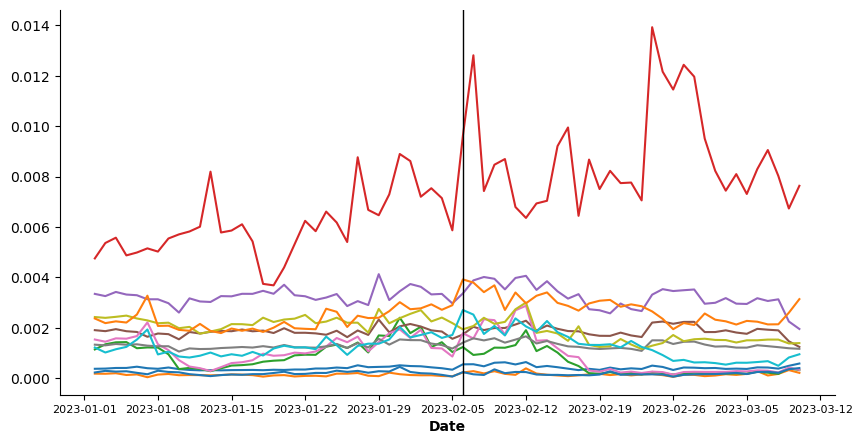

In [63]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

filter_cities = []

for layer in layers_POI:

    gdf_layer = gdf_cities_LU[gdf_cities_LU[layer]>0]
    if len(filter_cities):
        gdf_layer = gdf_layer[gdf_layer["city"].isin(filter_cities)]

    h3_in_layer = set(gdf_layer["hex_id"])
    activity_norm_layer = ts_USI[ts_USI.index.isin(h3_in_layer)]
    
    x = pd.to_datetime(activity_norm_layer.columns)
    y = activity_norm_layer.mean().values
    
    ax.plot(x,y, label=layer)

ax.axvline(EVENT_START, color="k", alpha=1, linewidth=1)

ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600);

In [64]:
df_hex_animation = (
    z_scores.reset_index()  # bring hex_id out of index
      .melt(id_vars="hex_id", var_name="timestamp", value_name="z_score"))

# Ensure timestamp is datetime
df_hex_animation["timestamp"] = pd.to_datetime(df_hex_animation["timestamp"])
df_hex_animation["timestamp"] = df_hex_animation["timestamp"].dt.strftime("%Y-%m-%dT%H:%M:%S")
df_hex_animation = df_hex_animation.round(2)
print(df_hex_animation.head())

            hex_id            timestamp  z_score
0  882c305695fffff  2023-01-02T00:00:00    -0.64
1  882c3056b3fffff  2023-01-02T00:00:00    -1.31
2  882c3056b9fffff  2023-01-02T00:00:00     0.85
3  882c3056bbfffff  2023-01-02T00:00:00    -0.73
4  882c344701fffff  2023-01-02T00:00:00    -0.95


In [ ]:
df_hex_animation.to_csv("hex_timeseries_data_earthquake.csv", index=False)

## 4. Conclusions and Key Findings

This analysis quantifies the impact of the 2023 Turkey-Syria earthquakes on urban activity patterns using anonymized mobility data and the Urban Space Usage Index.

The main findings are:

**1.** Observed activity increases on the day of the earthquake and peaks in the following days, reflecting a delayed response. This pattern is consistent with emergency response dynamics, including the mobilization of rescue operations, evacuations, and humanitarian assistance.

**2.** Z-scores reveal a statistically significant increase in activity during the event, with values reaching extreme anomaly levels relative to baseline conditions.

**3.** The spatial and functional distribution of activity is heterogeneous, with stronger anomalies in urban areas and transport infrastructure.

Overall, these results show that the proposed framework can effectively detect, quantify, and spatially characterize mobility responses to large-scale shocks, providing actionable insights for disaster response and urban resilience planning.

## Policy relevance
This analysis can support **disaster response and urban resilience planning** by showing how activity changes during and after a major shock. For the 2023 Turkey-Syria earthquakes, the results indicate a sharp increase in observed activity on the event day, followed by a delayed peak over the following days, consistent with evacuations, rescue operations, and humanitarian response. Since anomalies are concentrated in urban areas, transport corridors, and key service locations, these results can inform emergency logistics, transport and road management, shelter planning, healthcare access, and the allocation of response resources during the immediate aftermath of large-scale disasters.



## Limitations
This analysis is subject to some limitations. Mobility data may not fully represent the entire population, as it depends on smartphone usage and data coverage. In addition, spatial aggregation into H3 cells may smooth local variations.
In disaster contexts, mobility data may be further biased by infrastructure disruptions (e.g., network outages or power loss), which can reduce observed activity in the most severely affected areas.